In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
data = {
    "Customer_ID": ["C001", "C002", "C003", "C004", "C005", "C006", "C006", "C008", "C009", "C010"],
    "Name": ["Ahmed", "Mona", "Omar", "Sara", "Ali", "Nour", "Nour", "Youssef", "Hana", "Khaled"],
    "Age": [22, 28, np.nan, 35, 41, 25, 25, 29, 150, 33],
    "Gender": ["Male", "Female", "male", " Female ", "Male", "FEMALE", "FEMALE", "Male", "Female", "Male"],
    "City": ["Cairo", "Giza", "cairo", "Alexandria", "Giza", "cairo ", "cairo ", "Giza", "Cairo", "alexandria"],
    "Total_Spending": [450, 720, 850, np.nan, 1500, 600, 600, 900, 1200, 780]
}

df = pd.DataFrame(data)

df

,Customer_ID,Name,Age,Gender,City,Total_Spending
0,C001,Ahmed,22.0,Male,Cairo,450.0
1,C002,Mona,28.0,Female,Giza,720.0
2,C003,Omar,NaN,male,cairo,850.0
3,C004,Sara,35.0,Female,Alexandria,NaN
4,C005,Ali,41.0,Male,Giza,1500.0
5,C006,Nour,25.0,FEMALE,cairo,600.0
6,C006,Nour,25.0,FEMALE,cairo,600.0
7,C008,Youssef,29.0,Male,Giza,900.0
8,C009,Hana,150.0,Female,Cairo,1200.0
9,C010,Khaled,33.0,Male,alexandria,780.0


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(10, 6)

Missing Values:
Customer_ID       0
Name              0
Age               1
Gender            0
City              0
Total_Spending    1
dtype: int64

Duplicate Rows:
1

Data Types:
Customer_ID        object
Name               object
Age               float64
Gender             object
City               object
Total_Spending    float64
dtype: object


In [4]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Total_Spending"] = df["Total_Spending"].fillna(df["Total_Spending"].median())
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Customer_ID       0
Name              0
Age               0
Gender            0
City              0
Total_Spending    0
dtype: int64


In [5]:
df = df.drop_duplicates()
print("Duplicate rows after cleaning:")
print(df.duplicated().sum())
print("\nDataset shape after removing duplicates:")
print(df.shape)

Duplicate rows after cleaning:
0

Dataset shape after removing duplicates:
(9, 6)


In [7]:
df = df.copy()
df.loc[:, "Gender"] = df["Gender"].str.strip().str.title()
df.loc[:, "City"] = df["City"].str.strip().str.title()
print("Unique Gender values:")
print(df["Gender"].unique())
print("\nUnique City values:")
print(df["City"].unique())

Unique Gender values:
['Male' 'Female']

Unique City values:
['Cairo' 'Giza' 'Alexandria']


In [8]:
invalid_ages = df[(df["Age"] < 18) | (df["Age"] > 100)]
print("Unrealistic ages:")
print(invalid_ages[["Customer_ID", "Name", "Age"]])

Unrealistic ages:
  Customer_ID  Name    Age
8        C009  Hana  150.0


In [9]:
df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Age values after cleaning:")
print(df[["Customer_ID", "Name", "Age"]])

Age values after cleaning:
  Customer_ID     Name   Age
0        C001    Ahmed  22.0
1        C002     Mona  28.0
2        C003     Omar  29.0
3        C004     Sara  35.0
4        C005      Ali  41.0
5        C006     Nour  25.0
7        C008  Youssef  29.0
8        C009     Hana  29.0
9        C010   Khaled  33.0


In [10]:
print("===== FINAL DATA QUALITY CHECK =====")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nAge Range:")
print(f"Minimum Age: {df['Age'].min()}")
print(f"Maximum Age: {df['Age'].max()}")

print("\nUnique Gender Values:")
print(df["Gender"].unique())

print("\nUnique City Values:")
print(df["City"].unique())

print("\nFinal Dataset Shape:")
print(df.shape)

===== FINAL DATA QUALITY CHECK =====

Missing Values:
Customer_ID       0
Name              0
Age               0
Gender            0
City              0
Total_Spending    0
dtype: int64

Duplicate Rows:
0

Age Range:
Minimum Age: 22.0
Maximum Age: 41.0

Unique Gender Values:
['Male' 'Female']

Unique City Values:
['Cairo' 'Giza' 'Alexandria']

Final Dataset Shape:
(9, 6)


In [11]:
city_spending = df.groupby("City")["Total_Spending"].sum().sort_values(ascending=False)

print("Total Spending by City:")
print(city_spending)

Total Spending by City:
City
Giza          3120.0
Cairo         3100.0
Alexandria    1560.0
Name: Total_Spending, dtype: float64


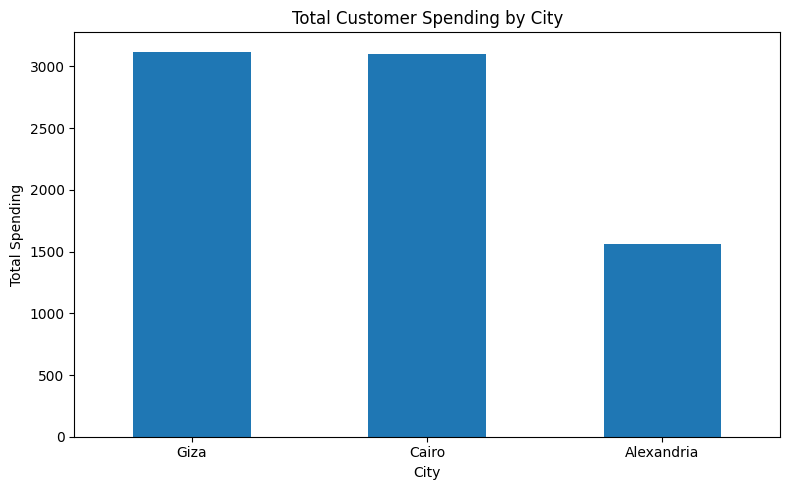

In [12]:
city_spending.plot(kind="bar", figsize=(8, 5))

plt.title("Total Customer Spending by City")
plt.xlabel("City")
plt.ylabel("Total Spending")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Business Insights

- Giza has the highest total customer spending at 3,120.
- Cairo is very close to Giza with total spending of 3,100.
- Alexandria has the lowest total customer spending at 1,560.
- The cleaned dataset can now be used for reliable customer analysis.
- Standardizing customer data improves the accuracy of future business decisions.